<a href="https://colab.research.google.com/github/brahmanbhavika06-sketch/my-colab-code/blob/main/Session_27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

# Create Dataset
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

print(df.head(10))
print("\nShape:", df.shape)

   Feature1  Feature2
0  0.830586 -0.447733
1  0.701678  0.816918
2  1.022080 -0.492571
3 -0.316765  0.953438
4  0.293226  1.057185
5  1.254903 -0.483435
6  1.053851 -0.442690
7  0.031380  1.053012
8  0.620545  0.713096
9  1.787657 -0.142959

Shape: (500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(pd.DataFrame(X_scaled,
                   columns=["Feature1","Feature2"]).head())

   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


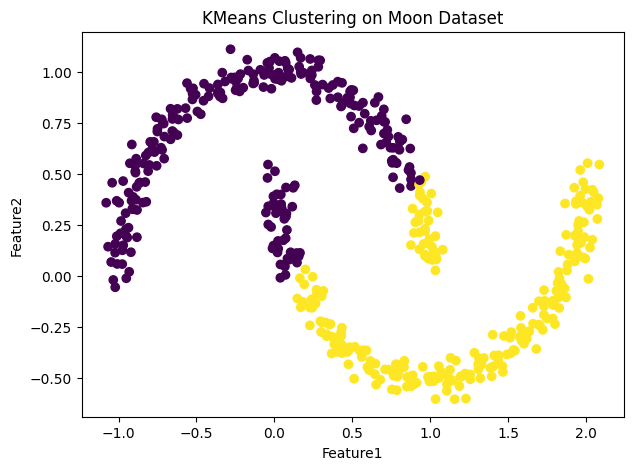

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(7,5))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["kmeans_cluster"],
    cmap="viridis"
)

plt.title("KMeans Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

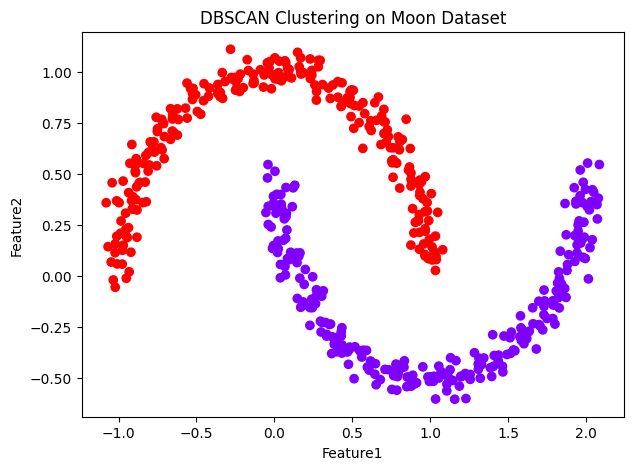

In [ ]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(7,5))
plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["dbscan_cluster"],
    cmap="rainbow"
)
plt.title("DBSCAN Clustering on Moon Dataset")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

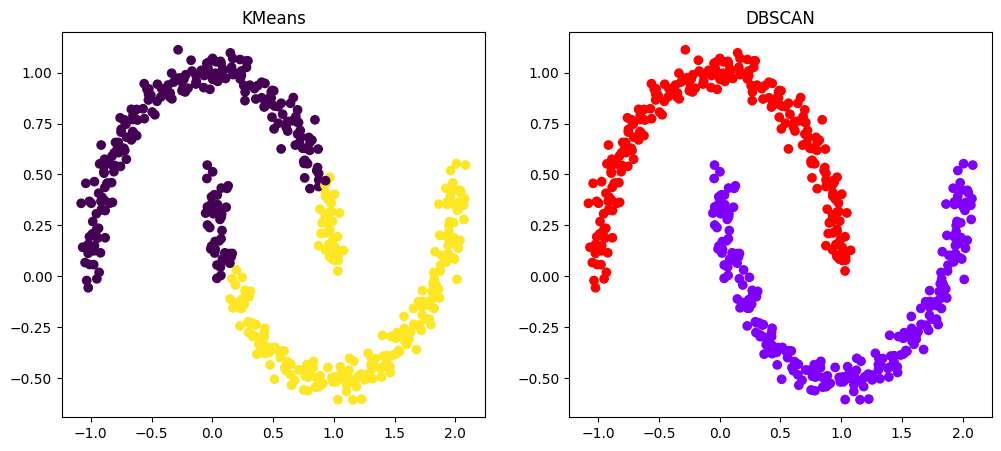

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["kmeans_cluster"],
    cmap="viridis"
)

plt.title("KMeans")

plt.subplot(1,2,2)

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["dbscan_cluster"],
    cmap="rainbow"
)

plt.title("DBSCAN")

plt.show()

In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5]

results = []

for eps in eps_values:

    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise = list(labels).count(-1)

    results.append([eps, n_clusters, noise])

result_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "Number of Clusters",
        "Noise Points"
    ]
)
print(result_df)

   eps  Number of Clusters  Noise Points
0  0.2                   2             0
1  0.3                   2             0
2  0.4                   2             0
3  0.5                   2             0


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Create Dataset
X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Output
print(X_scaled)
print("Shape =", X_scaled.shape)

[[-1.05251282  0.71908254  0.35044427  0.98965683 -1.61959701  1.41449866]
 [ 0.14079531 -1.04061999  0.84157371 -0.85710764  0.45873132 -0.55629338]
 [-0.14330172  1.11304882  0.7856684   0.68664305 -0.15354279 -1.52412444]
 ...
 [ 0.12079085 -0.78202579  0.52527576 -1.49949759  1.149061   -0.29441371]
 [-0.07572188  0.87357878  0.73479041  0.39837176 -0.36670079 -0.88491646]
 [-0.97217897  0.83710981  0.42247111  1.61220533 -1.23108893  2.11259434]]
Shape = (500, 6)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = y

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print()

print(pca_df.head())

Explained Variance Ratio:
[0.64327878 0.21039738]

        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1


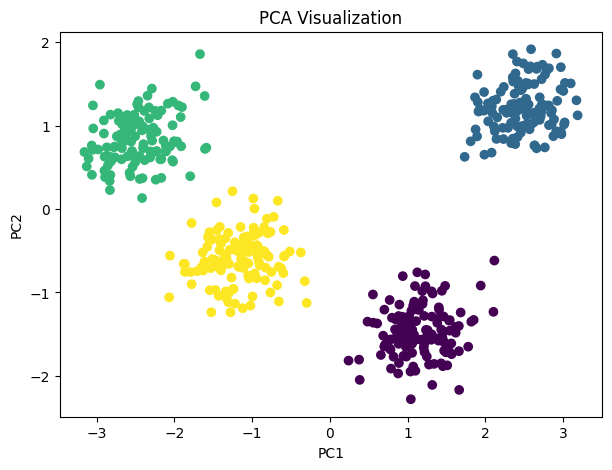

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis"
)

plt.title("PCA Visualization")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0    

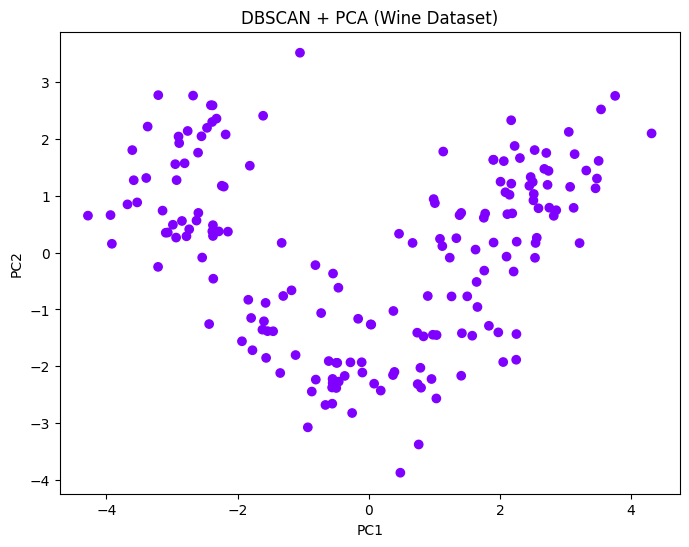

In [3]:
# Q10. Mini Project
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# 1. Load Wine Dataset
wine = load_wine()

# Select numerical features
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print("First 5 Rows:")
print(df.head())

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Apply DBSCAN
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

# Add cluster labels
df["Cluster"] = labels

print("\nDBSCAN Cluster Labels:")
print(df["Cluster"].value_counts())



# 4. Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = labels

print("\nPCA Data:")
print(pca_df.head())

# Explained Variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# 5. Visualize PCA Results
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="rainbow"
)

plt.title("DBSCAN + PCA (Wine Dataset)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()